# Per-Asset LSTM Training Notebook (Seq Length Tuning up to 30)

This notebook is adapted to your current project structure:

- raw and split CSV files live in `data/`
- preprocessed per-asset LSTM arrays live in `lstm_ready_data/`
- one LSTM model is trained **per asset**
- two variants are compared for every asset:
  - **baseline**: without the regime indicator
  - **regime-aware**: with the regime indicator

The notebook does three things in sequence:

1. checks the split boundaries and the 7-day target logic
2. tunes hyperparameters with **expanding-window CV on the train split only**
3. produces **7-day-ahead OOS forecasts** on validation and test

The sequence-length search is capped at **30** because the preprocessing notebook saved windows with `LOOKBACK = 30`. That means the training notebook can test shorter windows by slicing the saved arrays, but it cannot test anything longer than the saved base window.


## How to think about the saved `.npy` arrays

Each per-asset array already contains sliding windows.

For example, if preprocessing used `LOOKBACK = 30`, then a file like `X_train_BTCUSDT.npy` has shape:

\[
(	ext{samples}, 30, 	ext{features})
\]

So one sample is already a **30-day sequence**. During hyperparameter tuning, if we test `seq_len = 15`, we do **not** rebuild the window from scratch. We simply keep the **last 15 timesteps** from each saved 30-day block.

Example:

- saved sample: days `t-29` to `t`
- if `seq_len = 15`, the model sees only days `t-14` to `t`

That is why sequence-length tuning here is limited to values `<= 30`.


In [37]:
from pathlib import Path
import json
import random
import itertools
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## Configuration

This cell controls the directories, loss, search space, and tuning behaviour.

A few important design choices:

- `LOSS_NAME = "mse"` keeps the objective aligned with your forecasting goal.
- hyperparameter tuning is done on **train only** using expanding-window splits.
- the validation split is used only for **OOS validation forecasts** after tuning.
- the test split is used only for **final OOS test forecasts** after tuning and refitting on train+val.
- sequence lengths are restricted to values `<= 30`.


In [38]:
DATA_DIR = Path("data")
LSTM_DIR = Path("lstm_ready_data")
OUTPUT_DIR = Path("outputs_draft")
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_df.csv"
VAL_PATH   = DATA_DIR / "val_df.csv"
TEST_PATH  = DATA_DIR / "test_df.csv"
RAW_PANEL_PATH = DATA_DIR / "binance_data_raw.csv"

HORIZON = 7
LOSS_NAME = "mse"           # "mse" or "huber"
REGIME_LAST_FEATURE = True   # preprocessing notebook saves regime_label as the last feature
SEED = 42
USE_GPU_IF_AVAILABLE = True

# Hyperparameter tuning controls
N_CV_SPLITS = 3
RANDOM_SEARCH = True
N_RANDOM_CONFIGS = 18        # increase for a deeper search, reduce if runtime is too long
MAX_SEQ_LEN = 30             # capped by the preprocessing lookback
SEQ_LEN_CANDIDATES = [10, 15, 20, 25, 30]

PARAM_GRID = {
    "seq_len": SEQ_LEN_CANDIDATES,
    "learning_rate": [0.001, 0.0005, 0.0001, 0.00005],
    "hidden_size": [32, 64, 128],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.1, 0.2, 0.3],
    "batch_size": [32, 64],
    "epochs": [20, 35, 50],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "patience": [5],
}


## Reproducibility and device setup

The seed makes the random search and PyTorch training more stable across runs. The notebook will use GPU if PyTorch can see one.


In [39]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else "cpu"
print("Using device:", device)


Using device: cpu


## Load split CSVs and detect assets from the saved `.npy` files

The CSVs are used for boundary checks and for rebuilding the date metadata that tells us which forecast belongs to which asset/date. The actual model inputs come from the per-asset `.npy` arrays.


In [40]:
def sort_panel(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(["crypto", "date"]).reset_index(drop=True)

train_df = sort_panel(pd.read_csv(TRAIN_PATH, parse_dates=["date"]))
val_df   = sort_panel(pd.read_csv(VAL_PATH,   parse_dates=["date"]))
test_df  = sort_panel(pd.read_csv(TEST_PATH,  parse_dates=["date"]))

train_files = sorted(LSTM_DIR.glob("X_train_*.npy"))
assets = [p.stem.replace("X_train_", "") for p in train_files]

print("Train CSV shape:", train_df.shape)
print("Val CSV shape:  ", val_df.shape)
print("Test CSV shape: ", test_df.shape)
print("Detected assets:", assets)

if not assets:
    raise FileNotFoundError(
        f"No per-asset X_train_*.npy files found in {LSTM_DIR.resolve()}."
    )


Train CSV shape: (11448, 18)
Val CSV shape:   (2928, 18)
Test CSV shape:  (2864, 18)
Detected assets: ['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'LINKUSDT', 'LTCUSDT', 'XRPUSDT']


## Boundary and leakage sanity checks

The `target_7d` on a row dated `t` is meant to represent the return from `t+1` to `t+7`.

That means:

- the **last 7 rows** of train cannot safely be used for train targets if they would spill into validation
- the **last 7 rows** of validation cannot safely be used for validation targets if they would spill into test

The preprocessing notebook handled this by trimming the last 7 rows of each asset in train and validation before sequence creation. The code below rebuilds the same logic so we can verify the boundaries.


In [41]:
def trim_split_for_horizon(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    trimmed = []
    for asset, sub in df.groupby("crypto", sort=True):
        sub = sub.sort_values("date").copy()
        if len(sub) <= horizon:
            raise ValueError(f"Asset {asset} has only {len(sub)} rows; cannot trim horizon={horizon}.")
        trimmed.append(sub.iloc[:-horizon].copy())
    return pd.concat(trimmed, ignore_index=True)

safe_train = trim_split_for_horizon(train_df, HORIZON)
safe_val   = trim_split_for_horizon(val_df, HORIZON)
safe_test  = test_df.copy()  # preprocessing notebook assumes test was already made safe upstream

summary_rows = []
for split_name, df_ in {
    "train_raw": train_df,
    "train_safe": safe_train,
    "val_raw": val_df,
    "val_safe": safe_val,
    "test_used": safe_test,
}.items():
    counts = df_.groupby("crypto").size()
    summary_rows.append({
        "split": split_name,
        "date_min": df_["date"].min(),
        "date_max": df_["date"].max(),
        "rows_per_asset_min": int(counts.min()),
        "rows_per_asset_max": int(counts.max()),
    })

boundary_summary = pd.DataFrame(summary_rows)
display(boundary_summary)

if RAW_PANEL_PATH.exists():
    raw_panel = sort_panel(pd.read_csv(RAW_PANEL_PATH, parse_dates=["date"]))
    raw_max = raw_panel.groupby("crypto")["date"].max().rename("raw_max_date")
    test_max = test_df.groupby("crypto")["date"].max().rename("test_max_date")
    check = pd.concat([raw_max, test_max], axis=1).reset_index()
    check["days_between_raw_and_test_max"] = (check["raw_max_date"] - check["test_max_date"]).dt.days
    print("Optional raw-vs-test end-date check:")
    display(check)
else:
    print("Optional raw panel check skipped because data/binance_data_raw.csv was not found.")


,split,date_min,date_max,rows_per_asset_min,rows_per_asset_max
0,train_raw,2020-01-31,2023-12-31,1431,1431
1,train_safe,2020-01-31,2023-12-24,1424,1424
2,val_raw,2024-01-01,2024-12-31,366,366
3,val_safe,2024-01-01,2024-12-24,359,359
4,test_used,2025-01-01,2025-12-24,358,358


Optional raw-vs-test end-date check:


,crypto,raw_max_date,test_max_date,days_between_raw_and_test_max
0,ADAUSDT,2025-12-24,2025-12-24,0
1,BCHUSDT,2025-12-24,2025-12-24,0
2,BNBUSDT,2025-12-24,2025-12-24,0
3,BTCUSDT,2025-12-24,2025-12-24,0
4,ETHUSDT,2025-12-24,2025-12-24,0
5,LINKUSDT,2025-12-24,2025-12-24,0
6,LTCUSDT,2025-12-24,2025-12-24,0
7,XRPUSDT,2025-12-24,2025-12-24,0


## Rebuild metadata for each asset

The preprocessing notebook saved the `.npy` tensors, but for evaluation we still want to know:

- which asset a forecast belongs to
- which forecast-origin date the sample corresponds to

Because the per-asset `.npy` arrays were built with the original `LOOKBACK = 30`, we can rebuild the metadata from the CSV splits and then assert that the number of rebuilt dates matches the number of saved targets.


In [42]:
def load_asset_arrays(asset: str, data_dir: Path = LSTM_DIR):
    X_train = np.load(data_dir / f"X_train_{asset}.npy")
    y_train = np.load(data_dir / f"y_train_{asset}.npy")
    X_val   = np.load(data_dir / f"X_val_{asset}.npy")
    y_val   = np.load(data_dir / f"y_val_{asset}.npy")
    X_test  = np.load(data_dir / f"X_test_{asset}.npy")
    y_test  = np.load(data_dir / f"y_test_{asset}.npy")
    return X_train, y_train, X_val, y_val, X_test, y_test


def rebuild_meta_dates_for_asset(asset: str, base_lookback: int):
    train_asset = train_df[train_df["crypto"] == asset].sort_values("date").copy()
    val_asset   = val_df[val_df["crypto"] == asset].sort_values("date").copy()
    test_asset  = test_df[test_df["crypto"] == asset].sort_values("date").copy()

    train_safe_asset = train_asset.iloc[:-HORIZON].copy()
    val_safe_asset   = val_asset.iloc[:-HORIZON].copy()
    test_safe_asset  = test_asset.copy()

    def build_meta(current_df: pd.DataFrame, history_df: pd.DataFrame | None):
        if history_df is not None:
            combined = pd.concat([history_df, current_df], ignore_index=True)
            combined = (
                combined.drop_duplicates(subset=["date"], keep="last")
                        .sort_values("date")
                        .reset_index(drop=True)
            )
        else:
            combined = current_df.sort_values("date").reset_index(drop=True)

        current_dates = set(current_df["date"])
        dates = combined["date"].to_numpy()
        rows = []

        for end_idx in range(base_lookback - 1, len(combined)):
            if pd.Timestamp(dates[end_idx]) not in current_dates:
                continue
            rows.append({"crypto": asset, "date": pd.Timestamp(dates[end_idx])})

        return pd.DataFrame(rows)

    meta_train = build_meta(train_safe_asset, history_df=None)
    meta_val   = build_meta(val_safe_asset,   history_df=train_safe_asset)
    meta_test  = build_meta(test_safe_asset,  history_df=pd.concat([train_safe_asset, val_safe_asset], ignore_index=True))
    return meta_train, meta_val, meta_test

# Quick shape inspection using the first asset
example_asset = assets[0]
X_train_ex, y_train_ex, X_val_ex, y_val_ex, X_test_ex, y_test_ex = load_asset_arrays(example_asset)
print(f"Example asset: {example_asset}")
print("X_train shape:", X_train_ex.shape)
print("y_train shape:", y_train_ex.shape)
print("Saved base lookback:", X_train_ex.shape[1])


Example asset: ADAUSDT
X_train shape: (1395, 30, 12)
y_train shape: (1395,)
Saved base lookback: 30


## Model definition

The architecture is intentionally simple and transparent:

- LSTM stack with tunable `num_layers`
- tunable `hidden_size`
- dropout applied only when `num_layers > 1`
- one dense output layer producing a single 7-day-return forecast

This keeps the comparison between baseline and regime-aware models clean.


In [43]:
class CryptoLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden)
        return pred


## Training, prediction, and CV helpers

A few design choices matter here:

- **CV stage**: uses expanding-window train/validation splits inside the train sample and uses early stopping.
- **Validation OOS stage**: after tuning, the model is fit on the full train split for the chosen number of epochs and predicts the validation split.
- **Test OOS stage**: after tuning, the model is refit on **train + validation** for the chosen number of epochs and predicts the test split.

This keeps the final test forecast properly out-of-sample while still letting you use more data before the final test forecast.


In [ ]:
def get_loss_fn(loss_name: str):
    if loss_name.lower() == "mse":
        return nn.MSELoss()
    if loss_name.lower() == "huber":
        return nn.HuberLoss(delta=1.0)
    raise ValueError("LOSS_NAME must be 'mse' or 'huber'.")


def mse_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))


def mae_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def make_loader(X, y, batch_size: int, shuffle: bool):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def fit_model(
    model,
    train_loader,
    lr: float,
    epochs: int,
    loss_name: str,
    weight_decay: float = 0.0,
    device: str = "cpu",
    val_loader=None,
    patience: int | None = None,
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = get_loss_fn(loss_name)

    # learning rate scheduler
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',
    #     factor=0.5,
    #     patience=0
    # )

    best_state = None
    best_val_loss = float("inf")
    epochs_no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_train += loss.item() * X_batch.size(0)

        train_loss = running_train / len(train_loader.dataset)
        train_losses.append(train_loss)

        if val_loader is not None:
            model.eval()
            running_val = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)
                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)
                    running_val += loss.item() * X_batch.size(0)

            val_loss = running_val / len(val_loader.dataset)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if patience is not None and epochs_no_improve >= patience:
                break

    if val_loader is not None and best_state is not None:
        model.load_state_dict(best_state)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss if val_loader is not None else None,
        "epochs_trained": len(train_losses),
    }
    return model, history


def predict_model(model, X, device: str = "cpu", batch_size: int = 512):
    model = model.to(device)
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            batch_pred = model(X_batch).detach().cpu().numpy().reshape(-1)
            preds.append(batch_pred)
    return np.concatenate(preds)


def expanding_window_splits(n_obs: int, n_splits: int = 3, train_frac: float = 0.60, val_frac: float = 0.20):
    initial_train = max(30, int(n_obs * train_frac))
    val_size = max(15, int(n_obs * val_frac))

    if initial_train + val_size >= n_obs:
        raise ValueError("Training set is too short for the requested expanding-window CV setup.")

    remaining = n_obs - initial_train - val_size
    step = max(1, remaining // max(n_splits - 1, 1))

    splits = []
    for i in range(n_splits):
        train_end = initial_train + i * step
        val_start = train_end
        val_end = val_start + val_size
        if val_end <= n_obs:
            train_idx = np.arange(0, train_end)
            val_idx = np.arange(val_start, val_end)
            splits.append((train_idx, val_idx))

    if not splits:
        raise ValueError("No valid CV splits were created. Reduce n_splits or val_frac.")
    return splits


## Hyperparameter search space

The full grid is large, so by default this notebook uses **random search** over that grid. This is usually a better trade-off than exhaustive grid search when you have many assets and two model variants per asset.

Because the saved arrays already have a fixed base lookback, configs with `seq_len > saved_lookback` are dropped automatically.


In [45]:
all_configs = [dict(zip(PARAM_GRID.keys(), values)) for values in itertools.product(*PARAM_GRID.values())]

if RANDOM_SEARCH:
    n_pick = min(N_RANDOM_CONFIGS, len(all_configs))
    search_configs = random.sample(all_configs, k=n_pick)
else:
    search_configs = all_configs

print(f"Total possible configs: {len(all_configs)}")
print(f"Configs to evaluate:    {len(search_configs)}")
print("Candidate sequence lengths:", SEQ_LEN_CANDIDATES)


Total possible configs: 8640
Configs to evaluate:    18
Candidate sequence lengths: [10, 15, 20, 25, 30]


## Tuning logic

Two small transformations happen before the model sees the data:

1. if `use_regime = False`, the notebook drops the last feature, which is the regime indicator
2. if `seq_len < saved_lookback`, the notebook slices the last `seq_len` timesteps from each saved window

Then the config is scored with expanding-window CV on the train split.


In [46]:
def maybe_drop_regime(X: np.ndarray, use_regime: bool, regime_last_feature: bool = True) -> np.ndarray:
    if use_regime:
        return X
    if regime_last_feature:
        return X[:, :, :-1]
    raise ValueError("Notebook currently assumes regime indicator is the last feature when use_regime=False.")


def apply_seq_len(X: np.ndarray, seq_len: int) -> np.ndarray:
    if seq_len > X.shape[1]:
        raise ValueError(f"Requested seq_len={seq_len} but saved windows only have length {X.shape[1]}.")
    return X[:, -seq_len:, :]


def evaluate_config_cv(X_full, y, config, use_regime: bool, device: str):
    X_variant = maybe_drop_regime(X_full, use_regime=use_regime, regime_last_feature=REGIME_LAST_FEATURE)
    X_variant = apply_seq_len(X_variant, config["seq_len"])

    cv_losses = []
    splits = expanding_window_splits(len(X_variant), n_splits=N_CV_SPLITS)

    for train_idx, val_idx in splits:
        X_tr, y_tr = X_variant[train_idx], y[train_idx]
        X_va, y_va = X_variant[val_idx], y[val_idx]

        train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)
        val_loader   = make_loader(X_va, y_va, batch_size=config["batch_size"], shuffle=False)

        model = CryptoLSTM(
            input_size=X_variant.shape[2],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"],
        )

        model, history = fit_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            lr=config["learning_rate"],
            epochs=config["epochs"],
            patience=config["patience"],
            loss_name=LOSS_NAME,
            weight_decay=config["weight_decay"],
            device=device,
        )

        cv_losses.append(history["best_val_loss"])

    return float(np.mean(cv_losses))


def tune_variant(X_train_full, y_train, use_regime: bool, search_configs: list[dict], device: str):
    max_saved_lookback = min(X_train_full.shape[1], MAX_SEQ_LEN)
    valid_configs = [cfg for cfg in search_configs if cfg["seq_len"] <= max_saved_lookback]

    results = []
    best_config = None
    best_score = float("inf")

    for i, cfg in enumerate(valid_configs, start=1):
        score = evaluate_config_cv(X_train_full, y_train, cfg, use_regime=use_regime, device=device)
        results.append({"config_id": i, "cv_mse": score, **cfg})

        if score < best_score:
            best_score = score
            best_config = cfg

        print(f"[{'REG' if use_regime else 'BASE'}] config {i}/{len(valid_configs)} | cv_mse={score:.8f} | {cfg}")

    results_df = pd.DataFrame(results).sort_values("cv_mse").reset_index(drop=True)
    return best_config, results_df


## Final OOS forecast functions

After hyperparameter tuning:

- **validation forecasts** are produced by fitting on the full train split only
- **test forecasts** are produced by refitting on train + validation, then forecasting test

This is the main change that makes the final test stage stronger: the test model gets to learn from both train and validation after the hyperparameters have already been chosen.


In [47]:
def prepare_variant(X_full: np.ndarray, seq_len: int, use_regime: bool) -> np.ndarray:
    X_variant = maybe_drop_regime(X_full, use_regime=use_regime, regime_last_feature=REGIME_LAST_FEATURE)
    X_variant = apply_seq_len(X_variant, seq_len)
    return X_variant


def fit_for_validation_forecast(X_train_full, y_train, X_val_full, y_val, config, use_regime: bool, device: str):
    X_train_variant = prepare_variant(X_train_full, config["seq_len"], use_regime)
    X_val_variant   = prepare_variant(X_val_full,   config["seq_len"], use_regime)

    train_loader = make_loader(X_train_variant, y_train, batch_size=config["batch_size"], shuffle=True)
    model = CryptoLSTM(
        input_size=X_train_variant.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    )

    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=None,
        lr=config["learning_rate"],
        epochs=config["epochs"],
        patience=None,
        loss_name=LOSS_NAME,
        weight_decay=config["weight_decay"],
        device=device,
    )

    val_pred = predict_model(model, X_val_variant, device=device)
    metrics = {
        "val_mse": mse_score(y_val, val_pred),
        "val_mae": mae_score(y_val, val_pred),
        "val_da": directional_accuracy(y_val, val_pred),
    }
    return model, history, val_pred, metrics


def fit_for_test_forecast(X_train_full, y_train, X_val_full, y_val, X_test_full, y_test, config, use_regime: bool, device: str):
    X_train_variant = prepare_variant(X_train_full, config["seq_len"], use_regime)
    X_val_variant   = prepare_variant(X_val_full,   config["seq_len"], use_regime)
    X_test_variant  = prepare_variant(X_test_full,  config["seq_len"], use_regime)

    X_trainval = np.concatenate([X_train_variant, X_val_variant], axis=0)
    y_trainval = np.concatenate([y_train, y_val], axis=0)

    train_loader = make_loader(X_trainval, y_trainval, batch_size=config["batch_size"], shuffle=True)
    model = CryptoLSTM(
        input_size=X_trainval.shape[2],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    )

    model, history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=None,
        lr=config["learning_rate"],
        epochs=config["epochs"],
        patience=None,
        loss_name=LOSS_NAME,
        weight_decay=config["weight_decay"],
        device=device,
    )

    test_pred = predict_model(model, X_test_variant, device=device)
    metrics = {
        "test_mse": mse_score(y_test, test_pred),
        "test_mae": mae_score(y_test, test_pred),
        "test_da": directional_accuracy(y_test, test_pred),
    }
    return model, history, test_pred, metrics


## Main training loop

This loop does the following for each asset:

1. load the per-asset arrays
2. rebuild and verify metadata
3. tune the **baseline** model on train with expanding-window CV
4. tune the **regime-aware** model on train with expanding-window CV
5. produce OOS validation forecasts
6. refit on train+val and produce OOS test forecasts
7. save configs, metrics, histories, forecasts, and final model weights

Depending on the size of the random search and whether you have GPU, this can take a while.


In [48]:
all_summary_rows = []
all_forecast_rows = []

for asset in assets:
    print("=" * 90)
    print("Processing asset:", asset)

    X_train_full, y_train, X_val_full, y_val, X_test_full, y_test = load_asset_arrays(asset)
    base_lookback = X_train_full.shape[1]

    meta_train, meta_val, meta_test = rebuild_meta_dates_for_asset(asset, base_lookback=base_lookback)

    assert len(meta_train) == len(y_train), f"Meta mismatch in train for {asset}"
    assert len(meta_val) == len(y_val), f"Meta mismatch in val for {asset}"
    assert len(meta_test) == len(y_test), f"Meta mismatch in test for {asset}"

    # Asset-specific search space: respect the saved lookback and the hard cap of 30
    asset_search_configs = [cfg for cfg in search_configs if cfg["seq_len"] <= min(base_lookback, MAX_SEQ_LEN)]
    if not asset_search_configs:
        raise ValueError(f"No valid configs remain for {asset}. Saved lookback is {base_lookback}.")

    # -------------------------------------------------
    # Baseline model (without regime)
    # -------------------------------------------------
    print("Tuning baseline model...")
    best_base_config, base_tuning_df = tune_variant(
        X_train_full=X_train_full,
        y_train=y_train,
        use_regime=False,
        search_configs=asset_search_configs,
        device=device,
    )
    print("Best baseline config:", best_base_config)

    base_val_model, base_val_history, base_val_pred, base_val_metrics = fit_for_validation_forecast(
        X_train_full=X_train_full,
        y_train=y_train,
        X_val_full=X_val_full,
        y_val=y_val,
        config=best_base_config,
        use_regime=False,
        device=device,
    )

    base_test_model, base_test_history, base_test_pred, base_test_metrics = fit_for_test_forecast(
        X_train_full=X_train_full,
        y_train=y_train,
        X_val_full=X_val_full,
        y_val=y_val,
        X_test_full=X_test_full,
        y_test=y_test,
        config=best_base_config,
        use_regime=False,
        device=device,
    )

    # -------------------------------------------------
    # Regime-aware model (with regime)
    # -------------------------------------------------
    print("Tuning regime-aware model...")
    best_reg_config, reg_tuning_df = tune_variant(
        X_train_full=X_train_full,
        y_train=y_train,
        use_regime=True,
        search_configs=asset_search_configs,
        device=device,
    )
    print("Best regime config:", best_reg_config)

    reg_val_model, reg_val_history, reg_val_pred, reg_val_metrics = fit_for_validation_forecast(
        X_train_full=X_train_full,
        y_train=y_train,
        X_val_full=X_val_full,
        y_val=y_val,
        config=best_reg_config,
        use_regime=True,
        device=device,
    )

    reg_test_model, reg_test_history, reg_test_pred, reg_test_metrics = fit_for_test_forecast(
        X_train_full=X_train_full,
        y_train=y_train,
        X_val_full=X_val_full,
        y_val=y_val,
        X_test_full=X_test_full,
        y_test=y_test,
        config=best_reg_config,
        use_regime=True,
        device=device,
    )

    # -------------------------------------------------
    # Save outputs
    # -------------------------------------------------
    asset_dir = OUTPUT_DIR / asset
    asset_dir.mkdir(exist_ok=True)

    torch.save(base_test_model.state_dict(), asset_dir / "baseline_test_model.pt")
    torch.save(reg_test_model.state_dict(),  asset_dir / "regime_test_model.pt")

    with open(asset_dir / "baseline_best_config.json", "w") as f:
        json.dump(best_base_config, f, indent=2)
    with open(asset_dir / "regime_best_config.json", "w") as f:
        json.dump(best_reg_config, f, indent=2)

    pd.DataFrame({
        "epoch": np.arange(1, len(base_val_history["train_losses"]) + 1),
        "train_loss": base_val_history["train_losses"],
    }).to_csv(asset_dir / "baseline_val_fit_history.csv", index=False)

    pd.DataFrame({
        "epoch": np.arange(1, len(base_test_history["train_losses"]) + 1),
        "train_loss": base_test_history["train_losses"],
    }).to_csv(asset_dir / "baseline_test_fit_history.csv", index=False)

    pd.DataFrame({
        "epoch": np.arange(1, len(reg_val_history["train_losses"]) + 1),
        "train_loss": reg_val_history["train_losses"],
    }).to_csv(asset_dir / "regime_val_fit_history.csv", index=False)

    pd.DataFrame({
        "epoch": np.arange(1, len(reg_test_history["train_losses"]) + 1),
        "train_loss": reg_test_history["train_losses"],
    }).to_csv(asset_dir / "regime_test_fit_history.csv", index=False)

    base_tuning_df.to_csv(asset_dir / "baseline_tuning_results.csv", index=False)
    reg_tuning_df.to_csv(asset_dir / "regime_tuning_results.csv", index=False)

    # Forecast tables
    base_val_forecasts = meta_val.copy()
    base_val_forecasts["split"] = "val"
    base_val_forecasts["model_type"] = "baseline"
    base_val_forecasts["y_true"] = y_val
    base_val_forecasts["y_pred"] = base_val_pred

    base_test_forecasts = meta_test.copy()
    base_test_forecasts["split"] = "test"
    base_test_forecasts["model_type"] = "baseline"
    base_test_forecasts["y_true"] = y_test
    base_test_forecasts["y_pred"] = base_test_pred

    reg_val_forecasts = meta_val.copy()
    reg_val_forecasts["split"] = "val"
    reg_val_forecasts["model_type"] = "regime"
    reg_val_forecasts["y_true"] = y_val
    reg_val_forecasts["y_pred"] = reg_val_pred

    reg_test_forecasts = meta_test.copy()
    reg_test_forecasts["split"] = "test"
    reg_test_forecasts["model_type"] = "regime"
    reg_test_forecasts["y_true"] = y_test
    reg_test_forecasts["y_pred"] = reg_test_pred

    asset_forecasts = pd.concat(
        [base_val_forecasts, base_test_forecasts, reg_val_forecasts, reg_test_forecasts],
        ignore_index=True,
    )
    asset_forecasts.to_csv(asset_dir / "forecasts.csv", index=False)
    all_forecast_rows.append(asset_forecasts)

    # Summary rows
    all_summary_rows.extend([
        {
            "asset": asset,
            "model_type": "baseline",
            **base_val_metrics,
            **base_test_metrics,
            **{f"hp_{k}": v for k, v in best_base_config.items()},
        },
        {
            "asset": asset,
            "model_type": "regime",
            **reg_val_metrics,
            **reg_test_metrics,
            **{f"hp_{k}": v for k, v in best_reg_config.items()},
        },
    ])

summary_df = pd.DataFrame(all_summary_rows)
forecasts_df = pd.concat(all_forecast_rows, ignore_index=True)

summary_df.to_csv(OUTPUT_DIR / "summary_metrics.csv", index=False)
forecasts_df.to_csv(OUTPUT_DIR / "all_forecasts.csv", index=False)

print("Saved summary metrics to:", OUTPUT_DIR / "summary_metrics.csv")
print("Saved all forecasts to: ", OUTPUT_DIR / "all_forecasts.csv")
summary_df


Processing asset: ADAUSDT
Tuning baseline model...
[BASE] config 1/18 | cv_mse=0.00872512 | {'seq_len': 15, 'learning_rate': 0.001, 'hidden_size': 32, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 32, 'epochs': 50, 'weight_decay': 0.0, 'patience': 5}
[BASE] config 2/18 | cv_mse=0.00893661 | {'seq_len': 10, 'learning_rate': 0.001, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 64, 'epochs': 35, 'weight_decay': 1e-05, 'patience': 5}
[BASE] config 3/18 | cv_mse=0.00862326 | {'seq_len': 20, 'learning_rate': 0.0001, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'batch_size': 32, 'epochs': 50, 'weight_decay': 0.0, 'patience': 5}
[BASE] config 4/18 | cv_mse=0.00882397 | {'seq_len': 20, 'learning_rate': 0.0005, 'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2, 'batch_size': 64, 'epochs': 50, 'weight_decay': 1e-05, 'patience': 5}
[BASE] config 5/18 | cv_mse=0.00894001 | {'seq_len': 20, 'learning_rate': 0.001, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'batc

,asset,model_type,val_mse,val_mae,val_da,test_mse,test_mae,test_da,hp_seq_len,hp_learning_rate,hp_hidden_size,hp_num_layers,hp_dropout,hp_batch_size,hp_epochs,hp_weight_decay,hp_patience
0,ADAUSDT,baseline,0.017746,0.095995,0.498607,0.015018,0.095115,0.589385,20,0.00010,64,1,0.2,32,50,0.00000,5
1,ADAUSDT,regime,0.023650,0.103855,0.545961,0.019689,0.108187,0.511173,30,0.00100,32,1,0.0,32,20,0.00000,5
2,BCHUSDT,baseline,0.017894,0.097667,0.529248,0.007070,0.065057,0.606145,15,0.00050,32,2,0.3,32,20,0.00000,5
3,BCHUSDT,regime,0.023362,0.112378,0.504178,0.009761,0.078634,0.508380,10,0.00050,32,2,0.0,64,50,0.00001,5
4,BNBUSDT,baseline,0.016246,0.109091,0.509749,0.009393,0.063571,0.594972,10,0.00005,128,2,0.1,32,35,0.00010,5
5,BNBUSDT,regime,0.015628,0.096858,0.428969,0.008402,0.066453,0.539106,20,0.00050,32,2,0.2,64,50,0.00001,5
6,BTCUSDT,baseline,0.009712,0.079234,0.442897,0.002929,0.041383,0.466480,10,0.00005,128,2,0.1,32,35,0.00010,5
7,BTCUSDT,regime,0.030027,0.139511,0.459610,0.003443,0.046963,0.469274,15,0.00050,32,2,0.3,32,20,0.00000,5
8,ETHUSDT,baseline,0.018570,0.105020,0.498607,0.012550,0.079806,0.603352,10,0.00050,32,2,0.0,64,50,0.00001,5
9,ETHUSDT,regime,0.008466,0.072125,0.576602,0.009755,0.074683,0.555866,10,0.00005,128,2,0.1,32,35,0.00010,5


## Quick result views

The first table shows all saved summary metrics. The second table focuses on the test MSE difference between the regime-aware and baseline models.


In [49]:
summary_df = pd.read_csv(OUTPUT_DIR / "summary_metrics.csv")
display(summary_df.sort_values(["asset", "model_type"]).reset_index(drop=True))

pivot_test_mse = summary_df.pivot(index="asset", columns="model_type", values="test_mse")
pivot_test_mse["regime_minus_baseline"] = pivot_test_mse["regime"] - pivot_test_mse["baseline"]
display(pivot_test_mse.sort_index())


,asset,model_type,val_mse,val_mae,val_da,test_mse,test_mae,test_da,hp_seq_len,hp_learning_rate,hp_hidden_size,hp_num_layers,hp_dropout,hp_batch_size,hp_epochs,hp_weight_decay,hp_patience
0,ADAUSDT,baseline,0.017746,0.095995,0.498607,0.015018,0.095115,0.589385,20,0.00010,64,1,0.2,32,50,0.00000,5
1,ADAUSDT,regime,0.023650,0.103855,0.545961,0.019689,0.108187,0.511173,30,0.00100,32,1,0.0,32,20,0.00000,5
2,BCHUSDT,baseline,0.017894,0.097667,0.529248,0.007070,0.065057,0.606145,15,0.00050,32,2,0.3,32,20,0.00000,5
3,BCHUSDT,regime,0.023362,0.112378,0.504178,0.009761,0.078634,0.508380,10,0.00050,32,2,0.0,64,50,0.00001,5
4,BNBUSDT,baseline,0.016246,0.109091,0.509749,0.009393,0.063571,0.594972,10,0.00005,128,2,0.1,32,35,0.00010,5
5,BNBUSDT,regime,0.015628,0.096858,0.428969,0.008402,0.066453,0.539106,20,0.00050,32,2,0.2,64,50,0.00001,5
6,BTCUSDT,baseline,0.009712,0.079234,0.442897,0.002929,0.041383,0.466480,10,0.00005,128,2,0.1,32,35,0.00010,5
7,BTCUSDT,regime,0.030027,0.139511,0.459610,0.003443,0.046963,0.469274,15,0.00050,32,2,0.3,32,20,0.00000,5
8,ETHUSDT,baseline,0.018570,0.105020,0.498607,0.012550,0.079806,0.603352,10,0.00050,32,2,0.0,64,50,0.00001,5
9,ETHUSDT,regime,0.008466,0.072125,0.576602,0.009755,0.074683,0.555866,10,0.00005,128,2,0.1,32,35,0.00010,5


model_type,baseline,regime,regime_minus_baseline
asset,,,
ADAUSDT,0.015018,0.019689,0.004671
BCHUSDT,0.007070,0.009761,0.002692
BNBUSDT,0.009393,0.008402,-0.000990
BTCUSDT,0.002929,0.003443,0.000514
ETHUSDT,0.012550,0.009755,-0.002795
LINKUSDT,0.013001,0.016040,0.003039
LTCUSDT,0.022324,0.010851,-0.011473
XRPUSDT,0.040410,0.024843,-0.015566


## Optional: inspect one asset's tuning results and forecasts

Replace `ASSET_TO_INSPECT` with any asset code from the detected list if you want a closer look at that asset's hyperparameter search and forecast file.


In [50]:
ASSET_TO_INSPECT = assets[0]
asset_dir = OUTPUT_DIR / ASSET_TO_INSPECT

print("Inspecting asset:", ASSET_TO_INSPECT)
display(pd.read_csv(asset_dir / "baseline_tuning_results.csv").head())
display(pd.read_csv(asset_dir / "regime_tuning_results.csv").head())
display(pd.read_csv(asset_dir / "forecasts.csv").head())


Inspecting asset: ADAUSDT


,config_id,cv_mse,seq_len,learning_rate,hidden_size,num_layers,dropout,batch_size,epochs,weight_decay,patience
0,3,0.008623,20,0.00010,64,1,0.2,32,50,0.0000,5
1,17,0.008690,15,0.00005,64,2,0.0,64,50,0.0001,5
2,1,0.008725,15,0.00100,32,2,0.1,32,50,0.0000,5
3,8,0.008749,10,0.00005,32,2,0.3,32,20,0.0001,5
4,6,0.008768,15,0.00050,32,2,0.3,32,20,0.0000,5


,config_id,cv_mse,seq_len,learning_rate,hidden_size,num_layers,dropout,batch_size,epochs,weight_decay,patience
0,9,0.008644,30,0.00100,32,1,0.0,32,20,0.00000,5
1,18,0.008738,25,0.00005,128,2,0.1,64,50,0.00000,5
2,17,0.008782,15,0.00005,64,2,0.0,64,50,0.00010,5
3,7,0.008833,10,0.00005,128,2,0.1,32,35,0.00010,5
4,10,0.008858,10,0.00050,32,2,0.0,64,50,0.00001,5


,crypto,date,split,model_type,y_true,y_pred
0,ADAUSDT,2024-01-01,val,baseline,-0.141079,-0.056226
1,ADAUSDT,2024-01-02,val,baseline,-0.166123,-0.050170
2,ADAUSDT,2024-01-03,val,baseline,0.016208,-0.036848
3,ADAUSDT,2024-01-04,val,baseline,0.021010,-0.052894
4,ADAUSDT,2024-01-05,val,baseline,0.011387,-0.042031


## Optional plotting

This plot compares the predicted and actual 7-day returns for one chosen asset on the test split. It is just a quick visual sanity check, not a full evaluation.


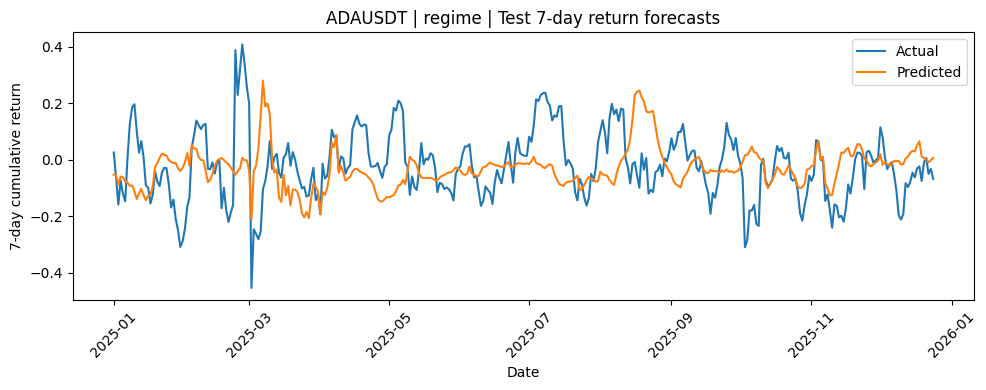

In [51]:
ASSET_TO_PLOT = assets[0]
PLOT_MODEL = "regime"   # choose "baseline" or "regime"

plot_df = pd.read_csv(OUTPUT_DIR / ASSET_TO_PLOT / "forecasts.csv", parse_dates=["date"])
plot_df = plot_df[(plot_df["split"] == "test") & (plot_df["model_type"] == PLOT_MODEL)].copy()

plt.figure(figsize=(10, 4))
plt.plot(plot_df["date"], plot_df["y_true"], label="Actual")
plt.plot(plot_df["date"], plot_df["y_pred"], label="Predicted")
plt.title(f"{ASSET_TO_PLOT} | {PLOT_MODEL} | Test 7-day return forecasts")
plt.xlabel("Date")
plt.ylabel("7-day cumulative return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


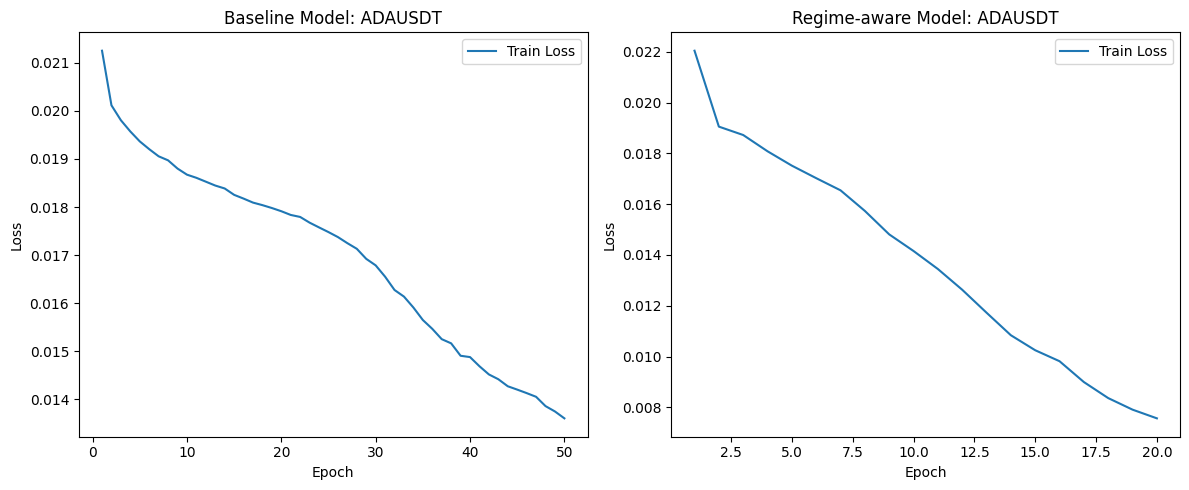

In [52]:
# Plot train and validation loss for best model configurations (baseline and regime) for a chosen asset
ASSET_TO_PLOT_LOSS = assets[0]  # Change as needed
asset_dir = OUTPUT_DIR / ASSET_TO_PLOT_LOSS

# Baseline
baseline_val_history = pd.read_csv(asset_dir / "baseline_val_fit_history.csv")
baseline_tuning = pd.read_csv(asset_dir / "baseline_tuning_results.csv")

# Regime-aware
regime_val_history = pd.read_csv(asset_dir / "regime_val_fit_history.csv")
regime_tuning = pd.read_csv(asset_dir / "regime_tuning_results.csv")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(baseline_val_history["epoch"], baseline_val_history["train_loss"], label="Train Loss")
# If validation loss is available, plot it (not always present if val_loader=None)
if "val_loss" in baseline_val_history.columns:
    plt.plot(baseline_val_history["epoch"], baseline_val_history["val_loss"], label="Val Loss")
plt.title(f"Baseline Model: {ASSET_TO_PLOT_LOSS}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(regime_val_history["epoch"], regime_val_history["train_loss"], label="Train Loss")
if "val_loss" in regime_val_history.columns:
    plt.plot(regime_val_history["epoch"], regime_val_history["val_loss"], label="Val Loss")
plt.title(f"Regime-aware Model: {ASSET_TO_PLOT_LOSS}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()